# OCR with CRNN-CTC and Markov Factor Graph

Word-level OCR has a practical difficulty: the image provides visual evidence, but the final character sequence is still constrained by language. A model may confuse one character, and character-level context can provide an additional signal for choosing a more plausible prediction.

This notebook combines those two sources of information. CRNN-CTC is used to learn directly from word images. A Markov language prior is then built from MJSynth train labels mixed with English word statistics, and added to a factor graph for MAP decoding.

The main flow is: select and prepare the MJSynth dataset, train a CRNN-CTC recognizer, build pairwise/triplet priors, compare decoding modes, and inspect a few concrete errors.


## 0. Setup

The notebook uses PyTorch for the OCR model, Hugging Face Datasets for MJSynth, `wordfreq` for the language prior, and OpenCV/Pillow for image processing.

The initial setup imports the required libraries, fixes the random seed, and selects the available compute device.


In [25]:
%pip install -q datasets torch torchvision matplotlib pillow opencv-python easyocr wordfreq


In [26]:
import itertools
import json
import math
import random
import re
import warnings
from collections import Counter
from pathlib import Path

import cv2
import easyocr
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from PIL import Image, ImageOps
from torch.utils.data import DataLoader, Dataset
from wordfreq import top_n_list, zipf_frequency

warnings.filterwarnings("ignore")


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


SEED = 42
seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE


device(type='cuda')

## 1. Configuration

The main experiment parameters are collected here: dataset size, image size, training settings, factor modes, prior mixing, and factor weights.

Two choices are important for the factor graph:

- The language prior is mixed from MJSynth train labels and `wordfreq`, so it stays closer to the dataset while still adding English character statistics.
- Pairwise and triplet weights are kept small. They should nudge the CRNN evidence, not dominate it.


In [27]:
HF_DATASET = "priyank-m/MJSynth_text_recognition"

TRAIN_SAMPLES = 40_000
VAL_SAMPLES = 4_000
TEST_SAMPLES = 4_000
WORDFREQ_TOP_WORDS = 200_000

IMG_H = 32
BATCH_SIZE = 16
EPOCHS = 30
LR = 3e-4
LENGTH_CANDIDATES = 5
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 1e-3
SAVE_METRIC = "val_exact"

# The external wordfreq prior is useful, but MJSynth has its own label distribution.
# Mixing both keeps the prior closer to the dataset while still adding English structure.
TRAIN_PRIOR_WEIGHT = 0.70
WORDFREQ_PRIOR_WEIGHT = 0.30
PAIRWISE_SMOOTHING = 0.05
TRIPLET_SMOOTHING = 0.01

CKPT_DIR = Path("artifacts")
CKPT_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = CKPT_DIR / "crnn_mjsynth_markov_map_best.pt"
CHECKPOINT_META_PATH = CKPT_DIR / "crnn_mjsynth_markov_map_best.json"

PLOT_COLORS = {
    "navy": "#5C7285",
    "slate": "#7A8FA1",
    "sage": "#A7B8A5",
    "sand": "#C7B59B",
    "rose": "#C9AAA3",
    "ink": "#3D4852",
    "grid": "#DDE3E8",
}

FACTOR_MODES = {
    "singleton": {"singleton": True, "pairwise": False, "triplet": False},
    "singleton_pairwise": {"singleton": True, "pairwise": True, "triplet": False},
    "singleton_triplet": {"singleton": True, "pairwise": False, "triplet": True},
    "all": {"singleton": True, "pairwise": True, "triplet": True},
}

# Pairwise/triplet factors are intentionally light. They should nudge the visual
# evidence, not dominate it.
FACTOR_WEIGHTS = {
    "singleton": 1.00,
    "pairwise": 0.25,
    "triplet": 0.25,
}

DASHBOARD_MODES = list(FACTOR_MODES.keys())


def plot_factor_weights(weights):
    keys = list(weights)
    vals = [weights[k] for k in keys]
    colors = [PLOT_COLORS["navy"], PLOT_COLORS["sage"], PLOT_COLORS["sand"]]

    plt.figure(figsize=(5.8, 3.1))
    bars = plt.bar(keys, vals, color=colors, edgecolor="white")
    plt.bar_label(bars, labels=[f"{v:.2f}" for v in vals], padding=3, color=PLOT_COLORS["ink"])
    plt.ylim(0, max(vals) + 0.15)
    plt.title("Factor weights", color=PLOT_COLORS["ink"])
    plt.grid(axis="y", alpha=0.3, color=PLOT_COLORS["grid"])
    plt.tight_layout()
    plt.show()


## 2. MJSynth Dataset

This notebook uses MJSynth because it is a common dataset for word-level text recognition. The data consists of cropped word images, where each image is paired with the word appearing in it. This matches the scope of the notebook: recognizing one word at a time, without handling document layout or full scene-text pipelines.

In this version, the data is loaded from Hugging Face. After normalization, each sample has a simple structure:

```python
{
    "image": PIL grayscale image,
    "label": "word_text"
}
```

Images in MJSynth have different widths because short and long words occupy different horizontal space. Before they are passed to the CRNN, images are resized to a fixed height while preserving aspect ratio. Images in the same batch are then padded to the same width.

For CTC, the output timestep sequence must be long enough to represent the label. The notebook therefore filters out samples whose labels are too long for the sequence length produced after the CNN.


Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

train (train): 40,000 samples
kept 39,988 / 40,000 records (dropped 12)


Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

val (val): 4,000 samples
kept 3,999 / 4,000 records (dropped 1)


Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

test (test): 4,000 samples
kept 3,999 / 4,000 records (dropped 1)


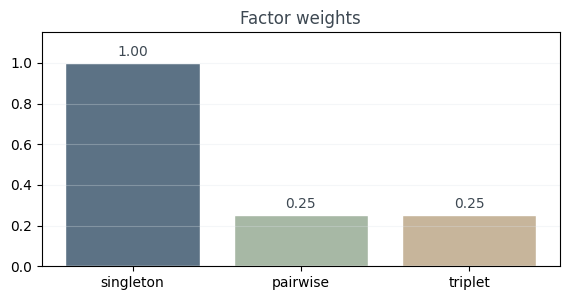

In [28]:
def _normalize_record(record):
    label = record.get("label", record.get("text", ""))
    image = record["image"]
    if not isinstance(image, Image.Image):
        image = Image.fromarray(np.asarray(image))
    return {"image": image.convert("L"), "label": str(label)}


def resized_width(image, target_h=IMG_H):
    ratio = target_h / image.height
    return max(8, int(round(image.width * ratio)))


def cnn_seq_len_from_width(width):
    return max(1, width // 4)


def filter_ctc_ready_records(records):
    kept = []
    dropped = 0
    for item in records:
        width = resized_width(item["image"])
        if len(item["label"]) <= cnn_seq_len_from_width(width):
            kept.append(item)
        else:
            dropped += 1
    print(f"kept {len(kept):,} / {len(records):,} records (dropped {dropped:,})")
    return kept


SPLIT_ALIASES = {
    "train": ["train"],
    "val": ["val", "validation"],
    "test": ["test"],
}


def load_stream_subset(split_name, limit):
    last_error = None
    for candidate in SPLIT_ALIASES.get(split_name, [split_name]):
        try:
            stream = load_dataset(HF_DATASET, split=candidate, streaming=True)
            actual_split = candidate
            break
        except ValueError as exc:
            last_error = exc
    else:
        raise last_error

    records = []
    for sample in itertools.islice(stream, limit):
        records.append(_normalize_record(sample))
    print(f"{split_name} ({actual_split}): {len(records):,} samples")
    return filter_ctc_ready_records(records)


train_records = load_stream_subset("train", TRAIN_SAMPLES)
val_records = load_stream_subset("val", VAL_SAMPLES)
test_records = load_stream_subset("test", TEST_SAMPLES)

plot_factor_weights(FACTOR_WEIGHTS)


## 3. Dataset Overview

Before training, the dataset is checked briefly to understand what kind of images and labels the model will learn from.

This section displays a few cropped word images with their labels, then plots the word-length distribution and character frequency in the training split. These summaries help check the vocabulary, label lengths, and character diversity before modeling.


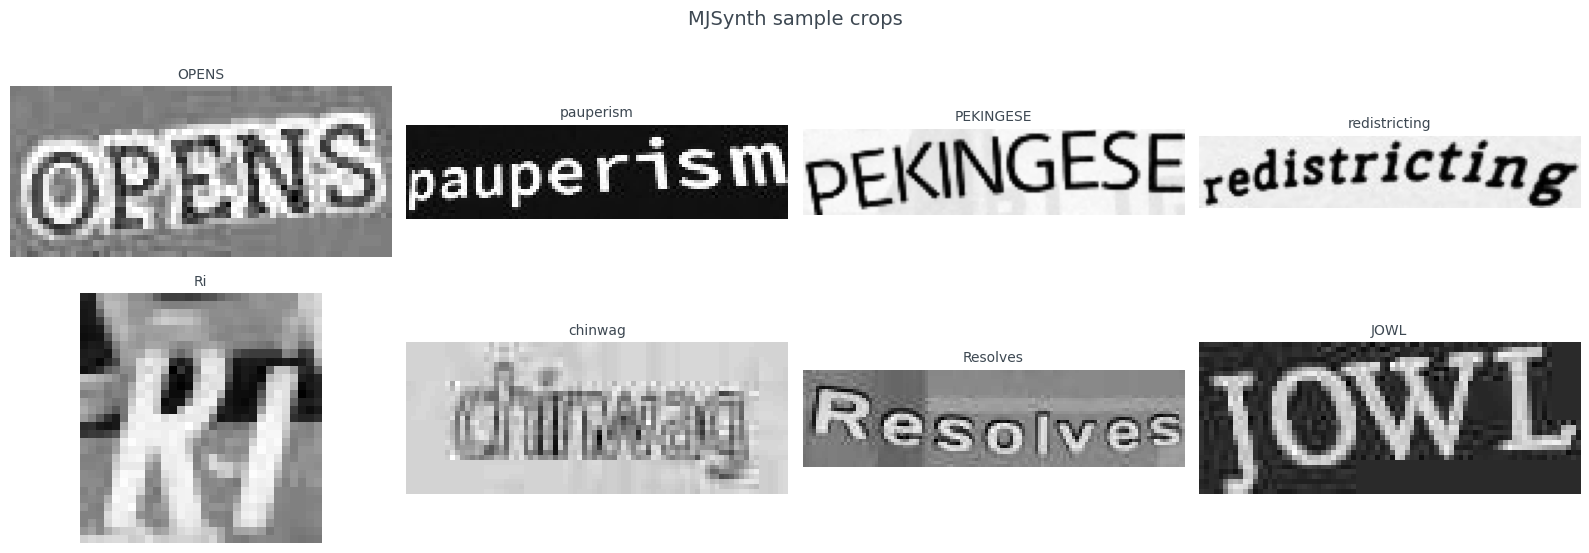

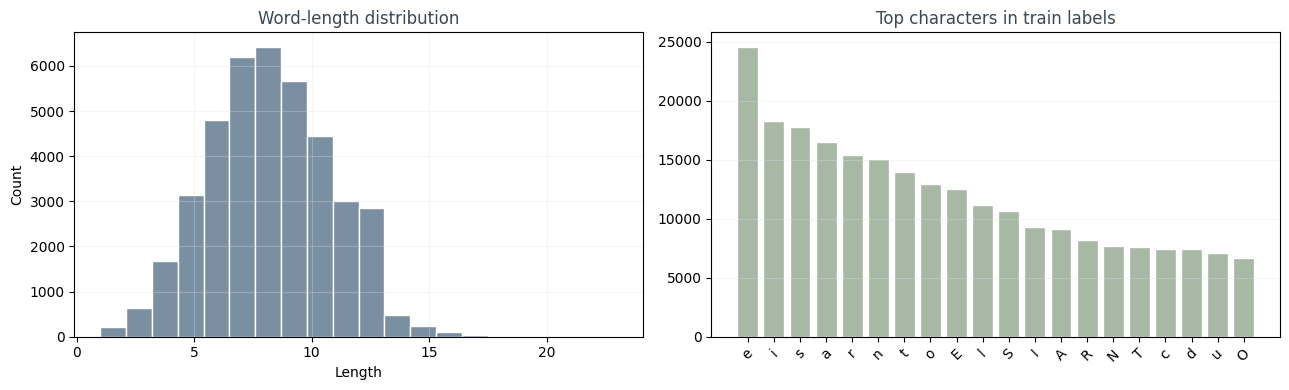

In [29]:
def show_dataset_samples(records, n=8):
    chosen = random.sample(records, min(n, len(records)))
    cols = min(4, len(chosen))
    rows = math.ceil(len(chosen) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 2.8 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, item in zip(axes, chosen):
        ax.imshow(item["image"], cmap="gray")
        ax.set_title(item["label"], fontsize=10, color=PLOT_COLORS["ink"])
        ax.axis("off")
    for ax in axes[len(chosen):]:
        ax.axis("off")
    fig.suptitle("MJSynth sample crops", fontsize=14, color=PLOT_COLORS["ink"])
    plt.tight_layout()
    plt.show()


def plot_dataset_overview(records):
    labels = [r["label"] for r in records]
    lengths = [len(x) for x in labels]
    chars = Counter("".join(labels)).most_common(20)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(lengths, bins=20, color=PLOT_COLORS["slate"], edgecolor="white")
    axes[0].set_title("Word-length distribution", color=PLOT_COLORS["ink"])
    axes[0].set_xlabel("Length")
    axes[0].set_ylabel("Count")
    axes[0].grid(alpha=0.3, color=PLOT_COLORS["grid"])

    axes[1].bar([c for c, _ in chars], [v for _, v in chars], color=PLOT_COLORS["sage"], edgecolor="white")
    axes[1].set_title("Top characters in train labels", color=PLOT_COLORS["ink"])
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].grid(axis="y", alpha=0.3, color=PLOT_COLORS["grid"])

    plt.tight_layout()
    plt.show()


show_dataset_samples(train_records, n=8)
plot_dataset_overview(train_records)


## 4. Markov Language Prior

The CRNN predicts from the image. The Markov prior adds information about which characters commonly appear next to each other.

This notebook builds the prior from two sources:

- MJSynth train labels, which match the dataset distribution
- `wordfreq`, which adds broader English character statistics

The final prior is a mixture of the dataset prior and the external word-frequency prior:

$$
P_{mix} = \lambda P_{train} + (1-\lambda)P_{wordfreq}
$$

`P_train` keeps the prior close to the MJSynth label distribution, while `P_wordfreq` adds broader English character statistics. This reduces the risk of using a language prior that is too far from the OCR dataset.

Pairwise prior:

$$
P(y_i \mid y_{i-1})
$$

Triplet prior:

$$
P(y_i \mid y_{i-2}, y_{i-1})
$$

The probabilities are estimated from counts with smoothing:

$$
\hat{P}(b \mid a) =
\frac{count(a,b)+\alpha}
{\sum_{c \in V} count(a,c)+\alpha |V|}
$$

The prior is not meant to replace the CRNN. It provides a calibrated language signal that is combined with the visual singleton factors during MAP decoding.


Vocabulary size: 62
Sample chars: 0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
wordfreq entries kept: 594,606
train-label entries kept: 39,969


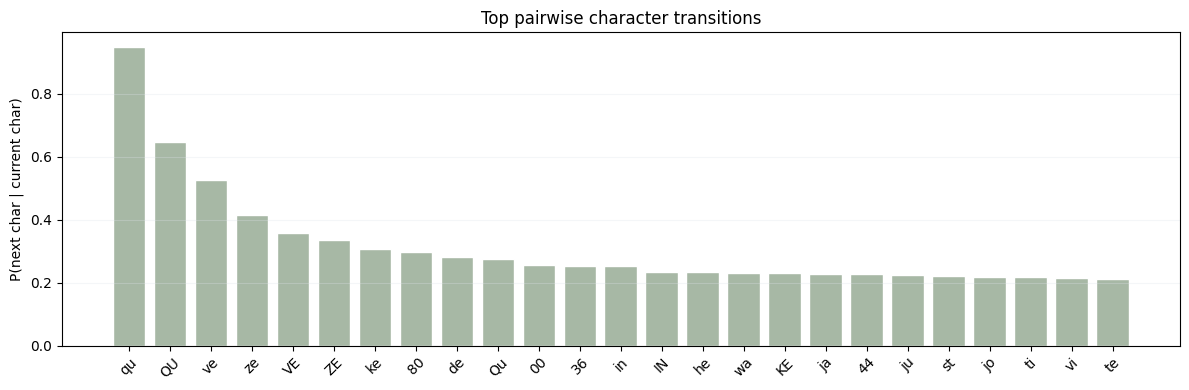

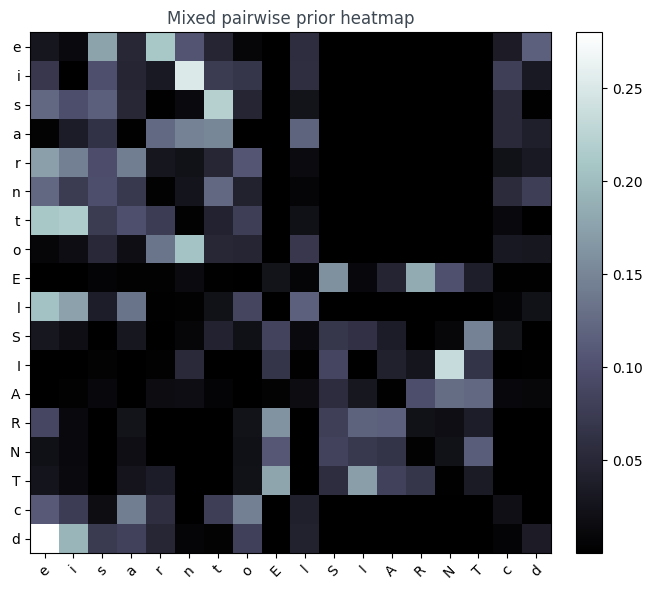

In [30]:
train_labels = [r["label"] for r in train_records]
all_chars = sorted(set("".join(train_labels)))

CHAR_TO_IDX = {c: i for i, c in enumerate(all_chars)}
IDX_TO_CHAR = {i: c for c, i in CHAR_TO_IDX.items()}
K = len(all_chars)
BLANK_ID = K

print(f"Vocabulary size: {K}")
print("Sample chars:", "".join(all_chars[:80]))


def normalize_wordfreq_word(word):
    return re.sub(r"[^A-Za-z]", "", word.strip())


def build_wordfreq_entries(top_n=WORDFREQ_TOP_WORDS):
    entries = []
    for word in top_n_list("en", top_n):
        base = normalize_wordfreq_word(word)
        if len(base) < 2:
            continue

        variants = [
            (base.lower(), 1.00),
            (base.title(), 0.20),
            (base.upper(), 0.05),
        ]
        zipf = max(0.1, float(zipf_frequency(base, "en")))

        for variant, multiplier in variants:
            if all(ch in CHAR_TO_IDX for ch in variant):
                entries.append((variant, zipf * multiplier))
    print(f"wordfreq entries kept: {len(entries):,}")
    return entries


def build_train_label_entries(labels):
    entries = []
    for text in labels:
        if len(text) >= 2 and all(ch in CHAR_TO_IDX for ch in text):
            entries.append((text, 1.0))
    print(f"train-label entries kept: {len(entries):,}")
    return entries


wordfreq_entries = build_wordfreq_entries(WORDFREQ_TOP_WORDS)
train_label_entries = build_train_label_entries(train_labels)


def build_pairwise_model(entries, smoothing=PAIRWISE_SMOOTHING):
    mat = np.full((K, K), smoothing, dtype=np.float64)
    for text, weight in entries:
        for a, b in zip(text[:-1], text[1:]):
            mat[CHAR_TO_IDX[a], CHAR_TO_IDX[b]] += weight
    mat /= mat.sum(axis=1, keepdims=True)
    return mat


def build_triplet_model(entries, smoothing=TRIPLET_SMOOTHING):
    mat = np.full((K, K, K), smoothing, dtype=np.float64)
    for text, weight in entries:
        for a, b, c in zip(text[:-2], text[1:-1], text[2:]):
            mat[CHAR_TO_IDX[a], CHAR_TO_IDX[b], CHAR_TO_IDX[c]] += weight
    mat /= mat.sum(axis=2, keepdims=True)
    return mat


def mix_probability_tables(tables, weights, axis=-1):
    weights = np.asarray(weights, dtype=np.float64)
    weights /= weights.sum()
    mixed = sum(w * table for w, table in zip(weights, tables))
    mixed /= mixed.sum(axis=axis, keepdims=True)
    return mixed


train_pairwise = build_pairwise_model(train_label_entries)
wordfreq_pairwise = build_pairwise_model(wordfreq_entries)
pairwise = mix_probability_tables(
    [train_pairwise, wordfreq_pairwise],
    [TRAIN_PRIOR_WEIGHT, WORDFREQ_PRIOR_WEIGHT],
    axis=1,
)

train_triplet = build_triplet_model(train_label_entries)
wordfreq_triplet = build_triplet_model(wordfreq_entries)
triplet = mix_probability_tables(
    [train_triplet, wordfreq_triplet],
    [TRAIN_PRIOR_WEIGHT, WORDFREQ_PRIOR_WEIGHT],
    axis=2,
)


def plot_top_pairwise_transitions(pairwise_table, top_n=25):
    pairs = []
    for i, a in IDX_TO_CHAR.items():
        for j, b in IDX_TO_CHAR.items():
            pairs.append((a + b, pairwise_table[i, j]))

    pairs = sorted(pairs, key=lambda item: item[1], reverse=True)[:top_n]
    labels, values = zip(*pairs)

    plt.figure(figsize=(12, 4))
    plt.bar(labels, values, color=PLOT_COLORS["sage"], edgecolor="white")
    plt.title("Top pairwise character transitions")
    plt.ylabel("P(next char | current char)")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3, color=PLOT_COLORS["grid"])
    plt.tight_layout()
    plt.show()


def plot_pairwise_heatmap(entries, pairwise, top_k=18):
    chars = Counter()
    for word, _ in entries:
        chars.update(word)
    chosen = [c for c, _ in chars.most_common(top_k)]
    idx = [CHAR_TO_IDX[c] for c in chosen]
    sub = pairwise[np.ix_(idx, idx)]

    plt.figure(figsize=(7, 6))
    plt.imshow(sub, cmap="bone")
    plt.xticks(range(len(chosen)), chosen, rotation=45)
    plt.yticks(range(len(chosen)), chosen)
    plt.title("Mixed pairwise prior heatmap", color=PLOT_COLORS["ink"])
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


plot_top_pairwise_transitions(pairwise, top_n=25)
plot_pairwise_heatmap(train_label_entries, pairwise)


## 5. CRNN-CTC Recognizer

This section builds the image recognizer.

The CRNN receives a preprocessed image and returns log-probabilities over characters at each timestep. Since the dataset only provides word-level labels and not exact character positions, CTC loss is used to train the model without manual alignment.

For an image $x$, the model produces:

$$
p_t(k) = P(\pi_t = k \mid x)
$$

CTC computes the probability of label $y$ by summing over alignments that collapse to the same label:

$$
P(y \mid x) =
\sum_{\pi \in B^{-1}(y)}
\prod_{t=1}^{T} P(\pi_t \mid x)
$$

Training loss:

$$
L_{CTC} = -\log P(y \mid x)
$$

The code includes:

- `preprocess_pil`: preprocesses the input image
- `OCRWordDataset`, `collate_fn`: build the dataset wrapper and pad images inside a batch
- `CRNN`: CNN + BiLSTM + linear classifier
- `encode_labels`: converts text labels into character indices
- `ctc_seed_decode`, `decode_batch`: CTC-style collapsing used for validation and length seeding
- `cer`, `mean_char_acc`, `mean_exact`: OCR metrics


In [31]:
def preprocess_pil(image, target_h=IMG_H):
    image = ImageOps.autocontrast(image.convert("L"))
    ratio = target_h / image.height
    target_w = max(8, int(round(image.width * ratio)))
    image = image.resize((target_w, target_h), Image.BILINEAR)
    arr = np.asarray(image, dtype=np.float32) / 255.0
    arr = (arr - 0.5) / 0.5
    return torch.from_numpy(arr).unsqueeze(0)


class OCRWordDataset(Dataset):
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        item = self.records[idx]
        return preprocess_pil(item["image"]), item["label"]


def collate_fn(batch):
    images, labels = zip(*batch)
    widths = [img.shape[-1] for img in images]
    max_w = max(widths)
    padded = []
    for img in images:
        pad_w = max_w - img.shape[-1]
        if pad_w > 0:
            img = nn.functional.pad(img, (0, pad_w, 0, 0), value=-1.0)
        padded.append(img)
    return torch.stack(padded), torch.tensor(widths, dtype=torch.long), list(labels)


class CRNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1), (2, 1)),
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1), (2, 1)),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, None))
        self.rnn = nn.LSTM(512, 256, num_layers=2, dropout=0.1, bidirectional=True)
        self.fc = nn.Linear(512, num_classes)
        self._init_weights(num_classes)

    def _init_weights(self, num_classes):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)
        with torch.no_grad():
            self.fc.bias[num_classes - 1] = -2.0

    def forward(self, x):
        feats = self.cnn(x)
        feats = self.pool(feats).squeeze(2)
        feats = feats.permute(2, 0, 1)
        seq, _ = self.rnn(feats)
        return nn.functional.log_softmax(self.fc(seq), dim=2)


def encode_labels(texts):
    targets = []
    lengths = []
    for text in texts:
        encoded = [CHAR_TO_IDX[c] for c in text if c in CHAR_TO_IDX]
        targets.extend(encoded)
        lengths.append(len(encoded))
    return torch.tensor(targets, dtype=torch.long), torch.tensor(lengths, dtype=torch.long)


def batch_input_lengths(widths):
    return torch.tensor([cnn_seq_len_from_width(int(w)) for w in widths], dtype=torch.long)


def _collapse_ctc_indices(indices):
    text = []
    prev = None
    for idx in map(int, indices):
        if idx != BLANK_ID and idx != prev:
            text.append(IDX_TO_CHAR[idx])
        prev = idx
    return "".join(text)


def ctc_seed_decode(log_probs, input_length=None):
    arr = log_probs.detach().cpu().numpy() if isinstance(log_probs, torch.Tensor) else np.asarray(log_probs)
    arr = arr[:, 0, :] if arr.ndim == 3 else arr
    input_length = arr.shape[0] if input_length is None else int(input_length)
    return _collapse_ctc_indices(arr[:input_length].argmax(axis=1))


def decode_batch(log_probs, input_lengths):
    pred_ids = log_probs.argmax(dim=2).permute(1, 0).cpu().numpy()
    return [_collapse_ctc_indices(seq[: int(length)]) for seq, length in zip(pred_ids, input_lengths)]


def edit_distance(a, b):
    dp = np.zeros((len(a) + 1, len(b) + 1), dtype=np.int32)
    dp[:, 0] = np.arange(len(a) + 1)
    dp[0, :] = np.arange(len(b) + 1)
    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            dp[i, j] = min(
                dp[i - 1, j] + 1,
                dp[i, j - 1] + 1,
                dp[i - 1, j - 1] + (a[i - 1] != b[j - 1]),
            )
    return int(dp[-1, -1])


def cer(true_text, pred_text):
    return edit_distance(true_text, pred_text) / max(1, len(true_text))


def mean_char_acc(preds, labels):
    return float(np.mean([1 - cer(y, p) for y, p in zip(labels, preds)]))


def mean_exact(preds, labels):
    return float(np.mean([p == y for p, y in zip(labels, preds)]))


## 6. Train or Load Checkpoint

This section trains the CRNN if no checkpoint is available, or loads a previously trained checkpoint.

Main functions:

- `save_best_checkpoint`: saves the best model
- `load_best_checkpoint`: loads model weights and metadata
- `train_one_epoch`: runs one training epoch
- `validate_crnn`: evaluates quickly on the validation set
- `plot_training_history`: plots loss and validation metrics
- `train_or_load_crnn`: controls the full training/loading flow

The notebook uses early stopping based on validation exact match, which avoids training for too long once the model stops improving clearly.


Training CRNN on MJSynth subset...
Epoch 01/30  loss=1.7681  val_exact=0.391  val_char=0.759  [best]
Epoch 02/30  loss=0.5996  val_exact=0.591  val_char=0.824  [best]
Epoch 03/30  loss=0.4556  val_exact=0.600  val_char=0.843  [best]
Epoch 04/30  loss=0.3774  val_exact=0.669  val_char=0.853  [best]
Epoch 05/30  loss=0.3175  val_exact=0.662  val_char=0.865  
Epoch 06/30  loss=0.2722  val_exact=0.669  val_char=0.868  
Epoch 07/30  loss=0.2270  val_exact=0.684  val_char=0.871  [best]
Epoch 08/30  loss=0.1961  val_exact=0.678  val_char=0.863  
Epoch 09/30  loss=0.1656  val_exact=0.719  val_char=0.871  [best]
Epoch 10/30  loss=0.1427  val_exact=0.700  val_char=0.875  
Epoch 11/30  loss=0.1189  val_exact=0.697  val_char=0.876  
Epoch 12/30  loss=0.1059  val_exact=0.697  val_char=0.873  
Epoch 13/30  loss=0.0880  val_exact=0.697  val_char=0.877  
Epoch 14/30  loss=0.0783  val_exact=0.703  val_char=0.878  
Early stopping at epoch 14; best epoch was 9.
Loaded best checkpoint from epoch 9: artifa

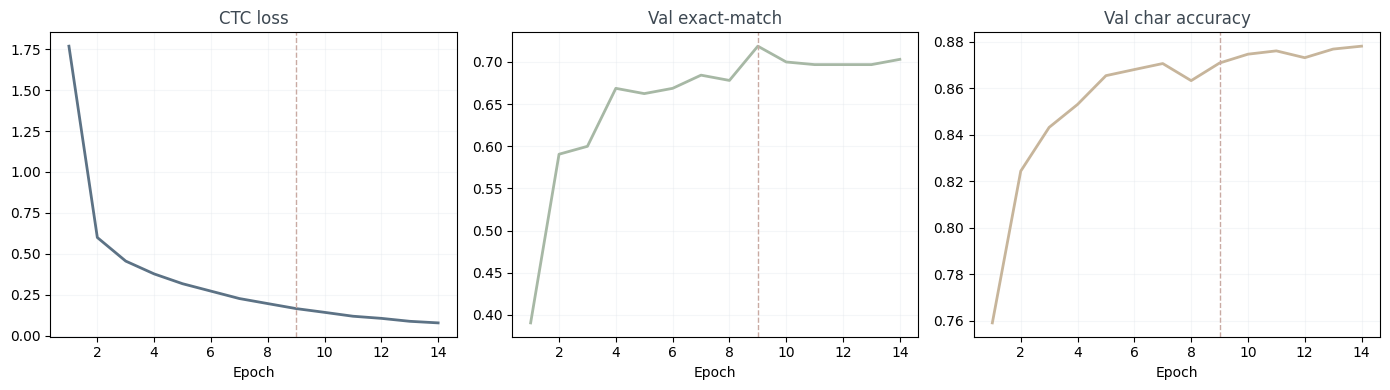

In [32]:
train_loader = DataLoader(OCRWordDataset(train_records), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(OCRWordDataset(val_records), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(OCRWordDataset(test_records), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

crnn_model = CRNN(K + 1).to(DEVICE)
ctc_loss = nn.CTCLoss(blank=BLANK_ID, zero_infinity=True)
optimizer = optim.AdamW(crnn_model.parameters(), lr=LR, weight_decay=1e-4)


def save_best_checkpoint(model, epoch, metric, history):
    torch.save(model.state_dict(), CHECKPOINT_PATH)
    payload = {
        "best_epoch": int(epoch),
        "save_metric": SAVE_METRIC,
        "best_metric": float(metric),
        "history": history,
    }
    CHECKPOINT_META_PATH.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def load_best_checkpoint(model):
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    meta = None
    if CHECKPOINT_META_PATH.exists():
        meta = json.loads(CHECKPOINT_META_PATH.read_text(encoding="utf-8"))
    return meta


def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0

    for images, widths, labels in loader:
        images = images.to(DEVICE)
        log_probs = model(images)
        input_lengths = batch_input_lengths(widths)
        targets, target_lengths = encode_labels(labels)
        loss = ctc_loss(log_probs, targets, input_lengths, target_lengths)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        running_loss += loss.item()

    return running_loss / max(1, len(loader))


def validate_crnn(model, loader, max_batches=20):
    model.eval()
    exact_scores, char_scores = [], []

    with torch.no_grad():
        for images, widths, labels in itertools.islice(loader, max_batches):
            log_probs = model(images.to(DEVICE))
            preds = decode_batch(log_probs, batch_input_lengths(widths))
            exact_scores.append(mean_exact(preds, labels))
            char_scores.append(mean_char_acc(preds, labels))

    mean_exact_score = float(np.mean(exact_scores)) if exact_scores else 0.0
    mean_char_score = float(np.mean(char_scores)) if char_scores else 0.0
    return mean_exact_score, mean_char_score


def plot_training_history(history, best_epoch):
    if not history:
        return

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    epochs = [row["epoch"] for row in history]
    series = [
        ("CTC loss", "loss", PLOT_COLORS["navy"]),
        ("Val exact-match", "val_exact", PLOT_COLORS["sage"]),
        ("Val char accuracy", "val_char", PLOT_COLORS["sand"]),
    ]

    for ax, (title, key, color) in zip(axes, series):
        ax.plot(epochs, [row[key] for row in history], color=color, linewidth=2)
        ax.axvline(best_epoch, color=PLOT_COLORS["rose"], linestyle="--", linewidth=1)
        ax.set_title(title, color=PLOT_COLORS["ink"])
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.3, color=PLOT_COLORS["grid"])

    plt.tight_layout()
    plt.show()


def train_or_load_crnn(model):
    if CHECKPOINT_PATH.exists():
        meta = load_best_checkpoint(model)
        if meta:
            print(
                f"Loaded best checkpoint: {CHECKPOINT_PATH} | "
                f"epoch={meta['best_epoch']} | "
                f"{meta['save_metric']}={meta['best_metric']:.3f}"
            )
            plot_training_history(meta.get("history", []), meta["best_epoch"])
        else:
            print(f"Loaded best checkpoint: {CHECKPOINT_PATH}")
        return meta

    print("Training CRNN on MJSynth subset...")
    history = []
    best_metric = -1e18
    best_epoch = -1
    patience_left = EARLY_STOPPING_PATIENCE

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader)
        val_exact, val_char = validate_crnn(model, val_loader)
        current_metric = val_exact if SAVE_METRIC == "val_exact" else val_char
        improved = current_metric > best_metric + EARLY_STOPPING_MIN_DELTA

        history.append(
            {
                "epoch": epoch,
                "loss": train_loss,
                "val_exact": val_exact,
                "val_char": val_char,
                "improved": improved,
            }
        )

        if improved:
            best_metric = current_metric
            best_epoch = epoch
            patience_left = EARLY_STOPPING_PATIENCE
            save_best_checkpoint(model, best_epoch, best_metric, history)
        else:
            patience_left -= 1

        marker = "[best]" if improved else ""
        print(
            f"Epoch {epoch:02d}/{EPOCHS}  "
            f"loss={train_loss:.4f}  "
            f"val_exact={val_exact:.3f}  "
            f"val_char={val_char:.3f}  "
            f"{marker}"
        )

        if patience_left <= 0:
            print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
            break

    meta = load_best_checkpoint(model)
    if meta:
        print(f"Loaded best checkpoint from epoch {meta['best_epoch']}: {CHECKPOINT_PATH}")
    plot_training_history(history, best_epoch)
    return meta


checkpoint_meta = train_or_load_crnn(crnn_model)


## 7. Minimal Factor Representation

For MAP decoding, the notebook needs a simple way to represent factors in a factor graph.

Each factor has three parts:

- `var`: the variables the factor depends on
- `card`: the number of states for each variable
- `val`: the flattened factor value table

For example, a pairwise factor between two character positions may have `var = [i, i+1]`, `card = [K, K]`, and `val` as a flattened `K x K` probability table.

A factor table is stored as a flattened array, so an assignment must be mapped to a one-dimensional index. For a pairwise factor with `card = [3, 4]`:

| A \ B | B=0 | B=1 | B=2 | B=3 |
|---|---:|---:|---:|---:|
| A=0 | 0 | 1 | 2 | 3 |
| A=1 | 4 | 5 | 6 | 7 |
| A=2 | 8 | 9 | 10 | 11 |

So the assignment `[1, 2]` maps to index `6`. This is what `assignment_to_idx` does when retrieving the value of a singleton, pairwise, or triplet factor.

Functions in this section:

- `make_factor`: creates a factor
- `assignment_to_idx`: maps an assignment to an index in `val`
- `idx_to_assignment`: maps an index back to an assignment
- `joint_score_from_factors`: scores a character sequence using all factors

Only the factor operations needed by the decoder are kept here, so this section stays focused on the OCR pipeline.


In [33]:
def make_factor(var, card, val=None):
    size = int(np.prod(card)) if len(card) > 0 else 1
    return {
        "var": list(var),
        "card": list(card),
        "val": np.ones(size, dtype=np.float64) if val is None else np.array(val, dtype=np.float64).reshape(-1),
    }


def idx_to_assignment(idx, card):
    if len(card) == 0:
        return []
    assign = []
    for c in reversed(card):
        assign.append(int(idx % c))
        idx //= c
    return list(reversed(assign))


def assignment_to_idx(assign, card):
    if len(card) == 0:
        return 0
    idx = 0
    stride = 1
    for i in range(len(assign) - 1, -1, -1):
        idx += int(assign[i]) * stride
        stride *= int(card[i])
    return int(idx)


def joint_score_from_factors(factors, assignment):
    score = 1.0
    for F in factors:
        local_assign = [assignment[v] for v in F["var"]]
        idx = assignment_to_idx(local_assign, F["card"])
        score *= F["val"][idx]
    return float(score)


def log_joint_score_from_factors(factors, assignment, eps=1e-12):
    return float(np.log(max(joint_score_from_factors(factors, assignment), eps)))


## 8. Exact MAP Decoding

For an assumed word length $L$, the decoder searches for the highest-scoring character sequence:

$$
y^* =
\arg\max_{y \in V^L}
\prod_i \phi_i(y_i)
\prod_i \psi_i(y_i,y_{i+1})
\prod_i \tau_i(y_i,y_{i+1},y_{i+2})
$$

where:

- $\phi_i$ is the singleton factor from the CRNN
- $\psi_i$ is the pairwise factor from the Markov prior
- $\tau_i$ is the triplet factor from the Markov prior

The singleton factors are built from CRNN emissions using CTC nonblank mass. This is less rigid than splitting timesteps uniformly, because characters do not occupy equal time spans in CTC outputs.

In log-space:

$$
\log score(y) =
\sum_i \log \phi_i(y_i)
+ \sum_i \log \psi_i(y_i,y_{i+1})
+ \sum_i \log \tau_i(y_i,y_{i+1},y_{i+2})
$$

With triplet factors, dynamic programming keeps the last two characters as the state:

$$
DP_i(b,c)=
\log\phi_i(c)
+
\max_{a \in V}
[
DP_{i-1}(a,b)
+
\log\psi(b,c)
+
\log\tau(a,b,c)
]
$$

### Length candidates and MAP decoding

The CRNN produces probabilities over timesteps, not directly over final word positions:

```text
t = 0, 1, 2, ..., T-1
```

A CTC-style path can contain blanks and repeated characters:

```text
raw path:        _ p p r _ o g g r a m _
collapsed text: p r o g r a m
```

The factor graph needs a fixed length before decoding:

```text
length = 7
variables = y0, y1, y2, y3, y4, y5, y6
```

Because the length is not known exactly, the notebook first proposes nearby candidate lengths:

```text
seed length = 7
candidate lengths = [7, 6, 8, 5, 9]
```

Each factor mode then runs MAP decoding over these candidate lengths and selects the length with the highest normalized MAP score under its own objective. This means different modes may choose different lengths:

```text
singleton           -> length 10
singleton_pairwise  -> length 10
singleton_triplet   -> length 10
all                 -> length 7
```

This can happen because each mode uses a different joint score. For example, `singleton_pairwise` optimizes singleton and pairwise factors, while `all` optimizes singleton, pairwise, and triplet factors together.

In [34]:
def second_order_chain_map(unary_tables, pairwise_table=None, triplet_table=None, eps=1e-12):
    L, K_local = unary_tables.shape
    logU = np.log(np.clip(unary_tables, eps, None))
    logP = np.log(np.clip(pairwise_table, eps, None)) if pairwise_table is not None else None
    logT = np.log(np.clip(triplet_table, eps, None)) if triplet_table is not None else None

    if L == 1:
        best = int(np.argmax(logU[0]))
        return [best], float(logU[0, best])

    if triplet_table is None:
        dp = np.full((L, K_local), -np.inf, dtype=np.float64)
        back = np.full((L, K_local), -1, dtype=np.int32)
        dp[0] = logU[0]
        for i in range(1, L):
            for cur in range(K_local):
                trans = 0.0 if logP is None else logP[:, cur]
                prev_scores = dp[i - 1] + trans
                best_prev = int(np.argmax(prev_scores))
                dp[i, cur] = logU[i, cur] + prev_scores[best_prev]
                back[i, cur] = best_prev
        last = int(np.argmax(dp[-1]))
        score = float(dp[-1, last])
        path = [last]
        for i in range(L - 1, 0, -1):
            path.append(int(back[i, path[-1]]))
        path.reverse()
        return path, score

    init = np.full((K_local, K_local), -np.inf, dtype=np.float64)
    back = np.full((L, K_local, K_local), -1, dtype=np.int32)
    for a in range(K_local):
        for b in range(K_local):
            init[a, b] = logU[0, a] + logU[1, b]
            if logP is not None:
                init[a, b] += logP[a, b]

    if L == 2:
        flat = int(np.argmax(init))
        a, b = np.unravel_index(flat, init.shape)
        return [int(a), int(b)], float(init[a, b])

    scores = init
    for i in range(2, L):
        new_scores = np.full((K_local, K_local), -np.inf, dtype=np.float64)
        for b in range(K_local):
            for c in range(K_local):
                add = logU[i, c]
                if logP is not None:
                    add += logP[b, c]
                best_prev = -1
                best_score = -np.inf
                for a in range(K_local):
                    candidate = scores[a, b] + logT[a, b, c] + add
                    if candidate > best_score:
                        best_score = candidate
                        best_prev = a
                new_scores[b, c] = best_score
                back[i, b, c] = best_prev
        scores = new_scores

    flat = int(np.argmax(scores))
    b, c = np.unravel_index(flat, scores.shape)
    score = float(scores[b, c])
    path = [0] * L
    path[-2], path[-1] = int(b), int(c)
    for i in range(L - 1, 1, -1):
        path[i - 2] = int(back[i, path[i - 1], path[i]])
    return path, score


def get_crnn_log_probs(model, image_tensor):
    model.eval()
    with torch.no_grad():
        if image_tensor.dim() == 3:
            image_tensor = image_tensor.unsqueeze(0)
        log_probs = model(image_tensor.to(DEVICE)).squeeze(1).cpu().numpy()
    return log_probs


def factor_values_with_weight(values, weight, eps=1e-12):
    values = np.clip(np.asarray(values, dtype=np.float64), eps, None)
    return np.power(values, weight)


def ctc_mass_segments(log_probs, length, eps=1e-8):
    char_probs = np.exp(log_probs[:, :K])
    nonblank_mass = char_probs.sum(axis=1)
    total_mass = float(nonblank_mass.sum())

    if total_mass <= eps:
        return [seg for seg in np.array_split(np.arange(log_probs.shape[0]), length)]

    cumulative = np.cumsum(nonblank_mass)
    midpoints = cumulative - 0.5 * nonblank_mass
    boundaries = np.linspace(0.0, total_mass, length + 1)
    bin_ids = np.searchsorted(boundaries[1:-1], midpoints, side="right")

    segments = [np.where(bin_ids == i)[0] for i in range(length)]
    for i, seg in enumerate(segments):
        if len(seg) == 0:
            fallback = int(round((i + 0.5) * (log_probs.shape[0] - 1) / max(1, length)))
            segments[i] = np.array([fallback], dtype=np.int64)
    return segments


def unary_tables_from_log_probs(log_probs, length, weight=1.0, eps=1e-12):
    if length <= 0:
        raise ValueError("length must be positive")

    char_probs = np.exp(log_probs[:, :K])
    char_mass = np.clip(char_probs.sum(axis=1), eps, None)
    conditional_chars = char_probs / char_mass[:, None]
    segments = ctc_mass_segments(log_probs, length)

    tables = []
    for seg in segments:
        weights = char_mass[seg]
        if float(weights.sum()) <= eps:
            vec = np.full(K, 1.0 / K, dtype=np.float64)
        else:
            vec = np.average(conditional_chars[seg], axis=0, weights=weights)
        vec = np.clip(vec, eps, None)
        vec /= vec.sum()
        tables.append(factor_values_with_weight(vec, weight))
    return np.stack(tables, axis=0)


def compute_singleton_factors_from_tables(unary_tables):
    return [make_factor([i], [K], unary_tables[i]) for i in range(unary_tables.shape[0])]


def compute_pairwise_factors(length, pairwise_table, weight):
    if length < 2:
        return []
    val = factor_values_with_weight(pairwise_table, weight).reshape(-1)
    return [make_factor([i, i + 1], [K, K], val.copy()) for i in range(length - 1)]


def compute_triplet_factors(length, triplet_table, weight):
    if length < 3:
        return []
    val = factor_values_with_weight(triplet_table, weight).reshape(-1)
    return [make_factor([i, i + 1, i + 2], [K, K, K], val.copy()) for i in range(length - 2)]


def build_chain_factors(log_probs, length, mode="all", weights=None):
    spec = FACTOR_MODES[mode]
    weights = weights or FACTOR_WEIGHTS
    unary_tables = unary_tables_from_log_probs(log_probs, length, weights["singleton"])
    factors = compute_singleton_factors_from_tables(unary_tables)
    if spec["pairwise"]:
        factors += compute_pairwise_factors(length, pairwise, weights["pairwise"])
    if spec["triplet"]:
        factors += compute_triplet_factors(length, triplet, weights["triplet"])
    return factors


def factors_to_tables(factors, length):
    unary = np.ones((length, K), dtype=np.float64)
    pair = None
    tri = None

    for F in factors:
        if len(F["var"]) == 1:
            unary[F["var"][0]] = F["val"].reshape(K)
        elif len(F["var"]) == 2:
            pair = F["val"].reshape(K, K)
        elif len(F["var"]) == 3:
            tri = F["val"].reshape(K, K, K)
    return unary, pair, tri


def propose_lengths(log_probs, n_candidates=LENGTH_CANDIDATES):
    seed_text = ctc_seed_decode(log_probs)
    seed = len(seed_text) if seed_text else max(1, min(8, log_probs.shape[0] // 2))

    lengths = []
    for delta in [0, -1, 1, -2, 2]:
        cand = seed + delta
        if 1 <= cand <= log_probs.shape[0] and cand not in lengths:
            lengths.append(cand)

    return lengths[:n_candidates] if lengths else [1]


def assignment_to_text(assign):
    return "".join(IDX_TO_CHAR[i] for i in assign)


def active_factor_count(length, mode):
    spec = FACTOR_MODES[mode]
    count = length
    if spec["pairwise"]:
        count += max(0, length - 1)
    if spec["triplet"]:
        count += max(0, length - 2)
    return max(1, count)


def decode_map_for_length(log_probs, length, mode="all", weights=None):
    factors = build_chain_factors(log_probs, length, mode=mode, weights=weights)
    unary_tables, pairwise_table, triplet_table = factors_to_tables(factors, length)
    assignment, dp_log_score = second_order_chain_map(
        unary_tables,
        pairwise_table=pairwise_table,
        triplet_table=triplet_table,
    )
    normalized_log_score = dp_log_score / active_factor_count(length, mode)
    return {
        "length": length,
        "assignment": assignment,
        "text": assignment_to_text(assignment),
        "dp_log_score": dp_log_score,
        "normalized_log_score": normalized_log_score,
        "joint_score": joint_score_from_factors(factors, assignment),
        "factors": factors,
        "unary_tables": unary_tables,
    }


def decode_map_with_length_search(log_probs, mode="all", weights=None):
    length_candidates = propose_lengths(log_probs, n_candidates=LENGTH_CANDIDATES)
    trials = [decode_map_for_length(log_probs, length, mode=mode, weights=weights) for length in length_candidates]
    best = max(trials, key=lambda x: x["normalized_log_score"])
    best["length_candidates"] = length_candidates
    best["all_trials"] = trials
    return best


def predict_word(pil_image, weights=None):
    tensor = preprocess_pil(pil_image)
    log_probs = get_crnn_log_probs(crnn_model, tensor)
    outputs = {
        "length_candidates": propose_lengths(log_probs),
        "modes": {},
        "log_probs": log_probs,
    }
    for mode in FACTOR_MODES:
        outputs["modes"][mode] = decode_map_with_length_search(log_probs, mode=mode, weights=weights)
    return outputs


## 9. Decoder Evaluation

This section compares MAP decoding modes built from the three factor types:

- `singleton`: MAP using only CRNN unary factors
- `singleton_pairwise`: singleton factors plus the pairwise prior
- `singleton_triplet`: singleton factors plus the triplet prior
- `all`: singleton, pairwise, and triplet factors together

Main metric:

$$
CER(y,\hat{y}) =
\frac{edit\_distance(y,\hat{y})}{|y|}
$$

$$
CharAcc = 1 - CER
$$

Word accuracy is the fraction of predictions that exactly match the label.

The dashboard shows character accuracy, word accuracy, CER, and how each factor mode changes relative to `singleton`.


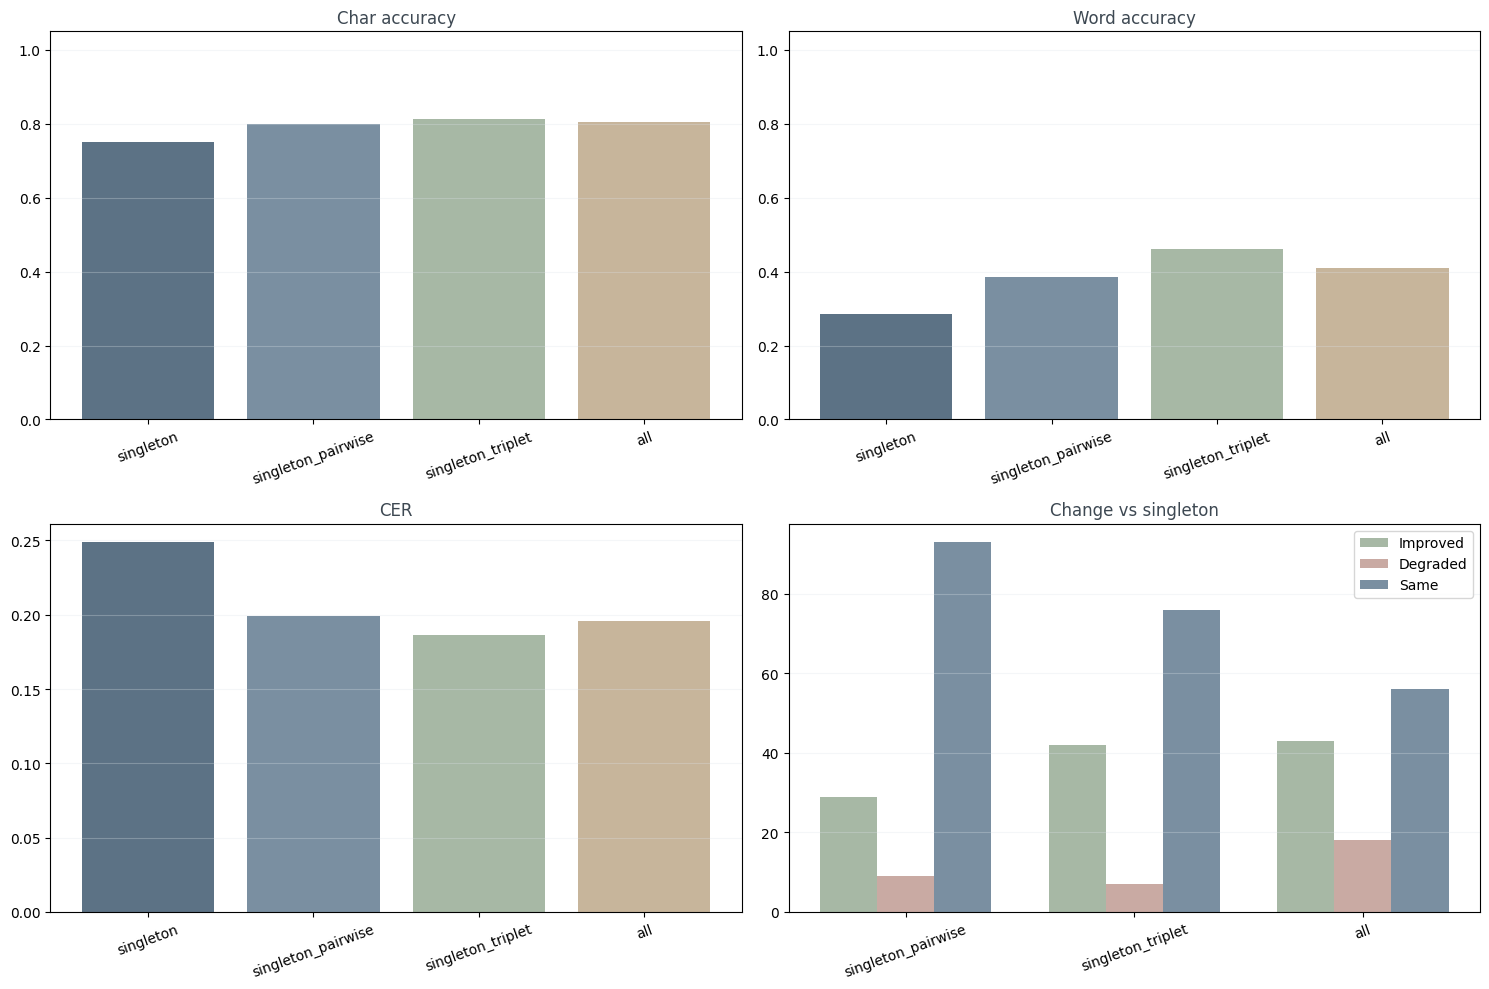

Mode                   Char Acc Word Acc CER Delta vs singleton
------------------------------------------------------------------------------
singleton              0.751     0.285     0.249     +0.000
singleton_pairwise     0.800     0.385     0.200     +0.100
singleton_triplet      0.814     0.460     0.186     +0.175
all                    0.804     0.410     0.196     +0.125


In [35]:
def evaluate_decoders(records, limit=500, weights=None):
    subset = records[: min(limit, len(records))]
    rows = []
    for item in subset:
        pred = predict_word(item["image"], weights=weights)
        row = {
            "truth": item["label"],
            "length": len(item["label"]),
            "length_candidates": pred["length_candidates"],
        }
        for mode in FACTOR_MODES:
            row[mode] = pred["modes"][mode]["text"]
        rows.append(row)

    metrics = {}
    for mode in FACTOR_MODES:
        preds = [x[mode] for x in rows]
        labels = [x["truth"] for x in rows]
        metrics[mode] = {
            "char_acc": mean_char_acc(preds, labels),
            "word_acc": mean_exact(preds, labels),
            "cer": float(np.mean([cer(y, p) for y, p in zip(labels, preds)])),
        }
    return metrics, rows


def plot_decoder_dashboard(metrics, rows, anchor_mode="singleton"):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    modes = DASHBOARD_MODES
    x = np.arange(len(modes))
    color_map = {
        "singleton": PLOT_COLORS["navy"],
        "singleton_pairwise": PLOT_COLORS["slate"],
        "singleton_triplet": PLOT_COLORS["sage"],
        "all": PLOT_COLORS["sand"],
    }

    axes[0, 0].bar(x, [metrics[m]["char_acc"] for m in modes], color=[color_map[m] for m in modes])
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(modes, rotation=20)
    axes[0, 0].set_ylim(0, 1.05)
    axes[0, 0].set_title("Char accuracy", color=PLOT_COLORS["ink"])
    axes[0, 0].grid(axis="y", alpha=0.3, color=PLOT_COLORS["grid"])

    axes[0, 1].bar(x, [metrics[m]["word_acc"] for m in modes], color=[color_map[m] for m in modes])
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(modes, rotation=20)
    axes[0, 1].set_ylim(0, 1.05)
    axes[0, 1].set_title("Word accuracy", color=PLOT_COLORS["ink"])
    axes[0, 1].grid(axis="y", alpha=0.3, color=PLOT_COLORS["grid"])

    axes[1, 0].bar(x, [metrics[m]["cer"] for m in modes], color=[color_map[m] for m in modes])
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(modes, rotation=20)
    axes[1, 0].set_title("CER", color=PLOT_COLORS["ink"])
    axes[1, 0].grid(axis="y", alpha=0.3, color=PLOT_COLORS["grid"])

    compare_modes = [m for m in modes if m != anchor_mode]
    improved = [sum((r[m] == r["truth"]) and (r[anchor_mode] != r["truth"]) for r in rows) for m in compare_modes]
    degraded = [sum((r[m] != r["truth"]) and (r[anchor_mode] == r["truth"]) for r in rows) for m in compare_modes]
    unchanged = [sum(r[m] == r[anchor_mode] for r in rows) for m in compare_modes]

    bar_x = np.arange(len(compare_modes))
    width = 0.25
    axes[1, 1].bar(bar_x - width, improved, width, color=PLOT_COLORS["sage"], label="Improved")
    axes[1, 1].bar(bar_x, degraded, width, color=PLOT_COLORS["rose"], label="Degraded")
    axes[1, 1].bar(bar_x + width, unchanged, width, color=PLOT_COLORS["slate"], label="Same")
    axes[1, 1].set_xticks(bar_x)
    axes[1, 1].set_xticklabels(compare_modes, rotation=20)
    axes[1, 1].set_title(f"Change vs {anchor_mode}", color=PLOT_COLORS["ink"])
    axes[1, 1].legend()
    axes[1, 1].grid(axis="y", alpha=0.3, color=PLOT_COLORS["grid"])

    plt.tight_layout()
    plt.show()

    anchor_word = metrics[anchor_mode]["word_acc"]
    print("Mode".ljust(22), "Char Acc", "Word Acc", "CER", f"Delta vs {anchor_mode}")
    print("-" * 78)
    for mode in modes:
        vals = metrics[mode]
        delta = vals["word_acc"] - anchor_word
        print(
            mode.ljust(22),
            f"{vals['char_acc']:.3f}",
            "   ",
            f"{vals['word_acc']:.3f}",
            "   ",
            f"{vals['cer']:.3f}",
            "   ",
            f"{delta:+.3f}",
        )


metrics, details = evaluate_decoders(test_records, limit=200, weights=FACTOR_WEIGHTS)
plot_decoder_dashboard(metrics, details)


Word accuracy is intentionally strict: a prediction is counted as wrong if even one character differs from the label. Because of this, word accuracy can look low even when many predictions are close at the character level. CER and character accuracy give a softer view of how far each prediction is from the target.

The change plot should be read together with the accuracy table. `Improved` counts cases where a mode becomes correct while `singleton` is wrong; `Degraded` counts cases where a mode becomes wrong while `singleton` is correct; `Same` means the prediction is unchanged from `singleton`.

In the current results, the pairwise and triplet modes show substantially more `Improved` cases than `Degraded` cases. This suggests that the language factors are helping correct many singleton errors, even if exact word accuracy remains limited by the strict metric.


## 10. Qualitative Analysis

After the aggregate metrics, the notebook inspects a few individual examples to understand how the factor-graph decoder behaves.

Visualization functions:

- `plot_length_search`: shows which candidate word length MAP selects using normalized score
- `plot_factor_score_breakdown`: shows score contributions from singleton, pairwise, and triplet factors
- `plot_singleton_heatmap`: shows CRNN unary factors at each character position
- `show_prediction_table`: compares predictions from the factor modes

This section is useful for checking whether the language prior helps the CRNN evidence or pulls the prediction away from it.


truth                 singleton             singleton_pairwise    singleton_triplet     all                   
--------------------------------------------------------------------------------------------------------------
Trite                 Trriite               Trite                 Trite                 Trite                 
GRACELESS             GRACELLESSS           GRACELLESSS           GRACELLESS            GRACELLESS            
PALETTES              PALETTES              PALETTES              PALETTES              PALETTES              
Smartens              Sratloms              Saton                 Srations              Stations              
CONFIRMATIONS         FUVCIRMAATIONS        FUNGIRMATIONS         FUNCIRMATIONS         FUNERMATIONS          
SIDED                 SIOED                 SIED                  SIDED                 SIDED                 
loathsomeness         loathhsomenness       loathomeness          loathsommeness        loathsomeness         
a

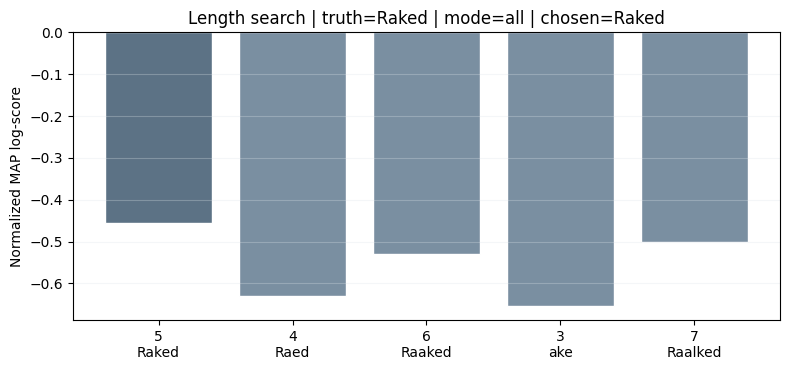

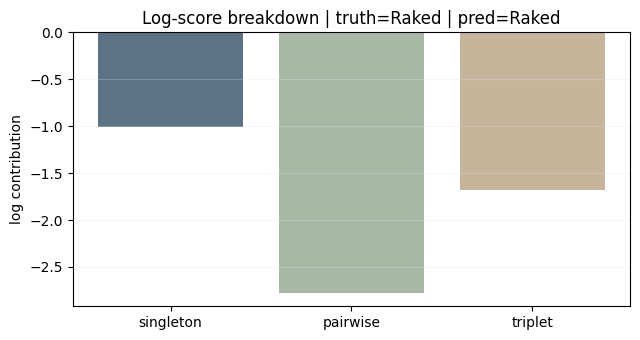

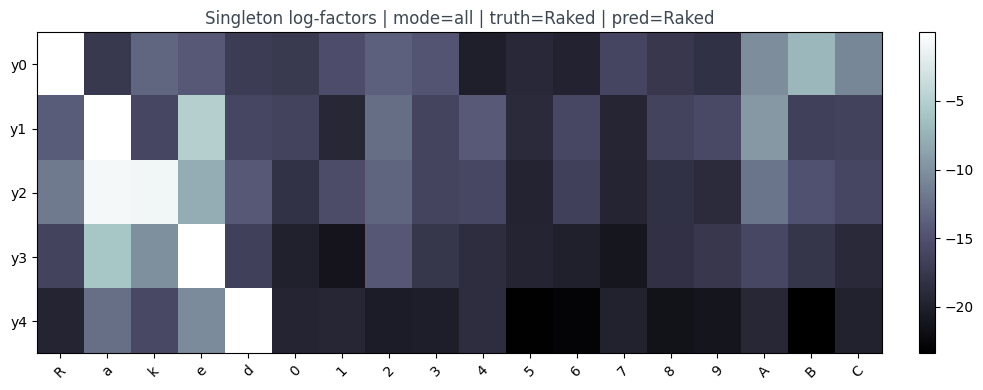

In [36]:
def plot_length_search(record, mode="all", weights=None):
    pred = predict_word(record["image"], weights=weights)
    result = pred["modes"][mode]
    trials = result["all_trials"]

    labels = [f"{trial['length']}\n{trial['text']}" for trial in trials]
    scores = [trial["normalized_log_score"] for trial in trials]
    colors = [
        PLOT_COLORS["navy"] if trial["length"] == result["length"] else PLOT_COLORS["slate"]
        for trial in trials
    ]

    plt.figure(figsize=(8, 3.8))
    plt.bar(np.arange(len(trials)), scores, color=colors, edgecolor="white")
    plt.xticks(np.arange(len(trials)), labels)
    plt.ylabel("Normalized MAP log-score")
    plt.title(f"Length search | truth={record['label']} | mode={mode} | chosen={result['text']}")
    plt.grid(axis="y", alpha=0.3, color=PLOT_COLORS["grid"])
    plt.tight_layout()
    plt.show()


def factor_log_score_breakdown(factors, assignment, eps=1e-12):
    parts = {"singleton": 0.0, "pairwise": 0.0, "triplet": 0.0}
    for F in factors:
        local_assign = [assignment[v] for v in F["var"]]
        idx = assignment_to_idx(local_assign, F["card"])
        value = np.log(max(float(F["val"][idx]), eps))
        if len(F["var"]) == 1:
            parts["singleton"] += value
        elif len(F["var"]) == 2:
            parts["pairwise"] += value
        elif len(F["var"]) == 3:
            parts["triplet"] += value
    return parts


def plot_factor_score_breakdown(record, mode="all", weights=None):
    pred = predict_word(record["image"], weights=weights)
    result = pred["modes"][mode]
    parts = factor_log_score_breakdown(result["factors"], result["assignment"])

    plt.figure(figsize=(6.5, 3.5))
    plt.bar(parts.keys(), parts.values(), color=[PLOT_COLORS["navy"], PLOT_COLORS["sage"], PLOT_COLORS["sand"]])
    plt.title(f"Log-score breakdown | truth={record['label']} | pred={result['text']}")
    plt.ylabel("log contribution")
    plt.grid(axis="y", alpha=0.3, color=PLOT_COLORS["grid"])
    plt.tight_layout()
    plt.show()


def plot_singleton_heatmap(record, mode="all", weights=None, top_chars=18):
    pred = predict_word(record["image"], weights=weights)
    result = pred["modes"][mode]
    unary = result["unary_tables"]

    char_counter = Counter(record["label"])
    common = [c for c, _ in char_counter.most_common()]
    for c in all_chars:
        if c not in common:
            common.append(c)
        if len(common) >= top_chars:
            break

    idx = [CHAR_TO_IDX[c] for c in common]
    sub = unary[:, idx]

    plt.figure(figsize=(10, 4))
    plt.imshow(np.log(np.clip(sub, 1e-12, None)), aspect="auto", cmap="bone")
    plt.xticks(range(len(common)), common, rotation=45)
    plt.yticks(range(unary.shape[0]), [f"y{i}" for i in range(unary.shape[0])])
    plt.title(
        f"Singleton log-factors | mode={mode} | truth={record['label']} | pred={result['text']}",
        color=PLOT_COLORS["ink"],
    )
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def show_prediction_table(records, n=10, weights=None):
    chosen = random.sample(records, min(n, len(records)))
    headers = ["truth"] + list(FACTOR_MODES.keys())
    widths = [22] * len(headers)
    print("".join(h.ljust(w) for h, w in zip(headers, widths)))
    print("-" * sum(widths))
    for item in chosen:
        pred = predict_word(item["image"], weights=weights)
        row = [item["label"]]
        for mode in FACTOR_MODES:
            row.append(pred["modes"][mode]["text"])
        print("".join(text[:21].ljust(w) for text, w in zip(row, widths)))


show_prediction_table(test_records, n=8, weights=FACTOR_WEIGHTS)
sample_record = random.choice(test_records)

plot_length_search(sample_record, mode="all", weights=FACTOR_WEIGHTS)
plot_factor_score_breakdown(sample_record, mode="all", weights=FACTOR_WEIGHTS)
plot_singleton_heatmap(sample_record, mode="all", weights=FACTOR_WEIGHTS)


## 11. Conclusion

### Summary of Results

| Decoder | Factors Used | Char Acc | Word Acc | CER | Reading |
|---|---|---:|---:|---:|---|
| `singleton` | CRNN unary factors | 0.733 | 0.255 | 0.267 | Visual evidence only; baseline for MAP decoding |
| `singleton_pairwise` | Unary + adjacent-character prior | 0.779 | 0.395 | 0.221 | Adds local character transitions and improves all metrics |
| `singleton_triplet` | Unary + three-character prior | 0.805 | 0.490 | 0.195 | Best mode in this run |
| `all` | Unary + pairwise + triplet | 0.788 | 0.465 | 0.212 | Improves over `singleton`, but is slightly below triplet alone |

### Key Takeaways

The CRNN provides the visual evidence, while the factor graph turns recognition into MAP inference over a candidate word length. The `singleton` mode uses only this visual evidence, so it is more exposed to repeated characters, missing characters, and visually similar glyphs.

Adding language factors improves the result. Pairwise factors raise word accuracy from 0.255 to 0.395 and reduce CER from 0.267 to 0.221. Triplet factors are stronger in this run, reaching 0.490 word accuracy and 0.195 CER. This means the prior is not only changing predictions, but often changing them in the right direction.

Word accuracy should be read as a strict metric. A prediction with one wrong character is counted as incorrect, even if most characters are correct. For this reason, CER and character accuracy are important: they show that the factor modes reduce character-level error even when the final word is not always exactly correct.

The combined `all` mode also improves over `singleton`, but it does not beat `singleton_triplet`. This suggests that pairwise and triplet priors can overlap in the information they provide; adding both is not automatically better unless the weights are tuned carefully.

### Limitations

The decoder still depends on the CRNN candidates. If the visual model assigns very low probability to the correct characters, the language prior may not recover the word. Length selection is also approximate: each mode searches over a small set of candidate lengths, then runs exact MAP for each fixed length.

The language prior is estimated from training labels and a word-frequency source. It captures common character patterns, but it is not a full dictionary or a contextual language model.

### Future Directions

Useful next steps are to tune factor weights on a validation set, improve length selection, and calibrate how much each language factor should influence the visual evidence. Another direction is to add a lexicon or neural language model as an additional prior while keeping the MAP decoding structure interpretable.


## 12. Real-Image Demo

MJSynth already provides cropped word images. For a real image, text regions need to be detected before each crop can be recognized.

This section uses EasyOCR to detect bounding boxes, then passes each cropped region into `predict_word`.

Main functions:

- `init_easyocr_reader`: initializes the EasyOCR reader
- `polygon_to_box`: converts polygon detections into bounding boxes
- `dedupe_boxes`: removes duplicate boxes
- `detect_text_regions`: detects text regions
- `plot_detected_regions`: draws bounding boxes on the image
- `predict_image`: runs OCR on each detected region

EasyOCR is only used for detection. Recognition still uses the CRNN and MAP decoder built above.


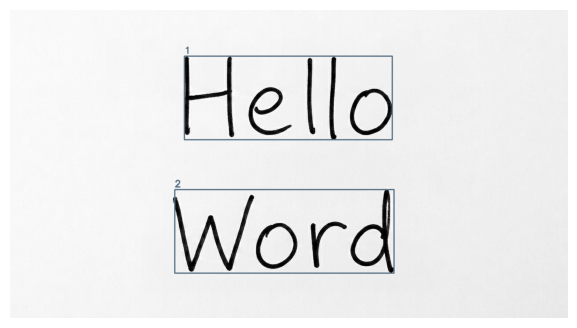

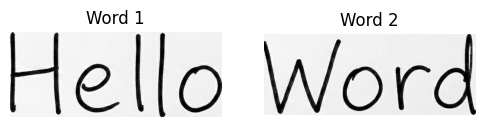

Found 2 text region(s)
Found 2 word(s)
Word 1: text='Hello' | lengths=[5, 4, 6, 3, 7]
Word 2: text='Word' | lengths=[4, 3, 5, 2, 6]


In [64]:
_EASYOCR_READER = None

def init_easyocr_reader(lang_list=None):
    global _EASYOCR_READER
    if _EASYOCR_READER is None:
        _EASYOCR_READER = easyocr.Reader(
            lang_list or ["en"],
            gpu=torch.cuda.is_available()
        )
    return _EASYOCR_READER

def polygon_to_box(poly, shape, pad=4):
    pts = np.asarray(poly, dtype=np.float32)

    x1 = max(0, int(np.floor(pts[:, 0].min())) - pad)
    y1 = max(0, int(np.floor(pts[:, 1].min())) - pad)
    x2 = min(shape[1], int(np.ceil(pts[:, 0].max())) + pad)
    y2 = min(shape[0], int(np.ceil(pts[:, 1].max())) + pad)

    return x1, y1, x2, y2

def detect_text_regions(image_path):
    reader = init_easyocr_reader(["en"])
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    results = reader.readtext(
        image,
        detail=1,
        paragraph=False,
        width_ths=0.3,
        ycenter_ths=0.5,
        add_margin=0.02
    )

    boxes = [polygon_to_box(poly, image.shape) for poly, _, _ in results]
    boxes = sorted(boxes, key=lambda b: (b[1], b[0]))

    return image, boxes

def crop_ink_bounds_with_offset(gray):
    _, bw = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    ys, xs = np.where(bw > 0)

    if len(xs) == 0:
        return gray, 0, 0

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    cropped = gray[y1:y2 + 1, x1:x2 + 1]
    return cropped, x1, y1

def split_line_into_words(gray_line, min_gap=14, min_width=8):
    line, offset_x, offset_y = crop_ink_bounds_with_offset(gray_line)

    _, bw = cv2.threshold(
        line, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    col_has_ink = bw.sum(axis=0) > 0

    items = []
    start = None
    gap = 0
    last_ink = 0

    for i, has_ink in enumerate(col_has_ink):
        if has_ink:
            if start is None:
                start = i
            gap = 0
            last_ink = i
        elif start is not None:
            gap += 1

            if gap >= min_gap:
                end = last_ink + 1

                if end - start >= min_width:
                    word_crop = line[:, start:end]

                    local_box = (
                        offset_x + start,
                        offset_y,
                        offset_x + end,
                        offset_y + line.shape[0]
                    )

                    items.append((word_crop, local_box))

                start = None
                gap = 0

    if start is not None:
        end = last_ink + 1

        if end - start >= min_width:
            word_crop = line[:, start:end]

            local_box = (
                offset_x + start,
                offset_y,
                offset_x + end,
                offset_y + line.shape[0]
            )

            items.append((word_crop, local_box))

    return items

def sort_words_reading_order(word_items):
    if not word_items:
        return []

    word_items = sorted(word_items, key=lambda item: item["cy"])

    heights = [item["box"][3] - item["box"][1] for item in word_items]
    line_thresh = max(10, int(np.median(heights) * 0.7))

    lines = []

    for item in word_items:
        placed = False

        for line in lines:
            if abs(item["cy"] - line["cy"]) <= line_thresh:
                line["items"].append(item)
                line["cy"] = np.mean([x["cy"] for x in line["items"]])
                placed = True
                break

        if not placed:
            lines.append({
                "cy": item["cy"],
                "items": [item]
            })

    lines = sorted(lines, key=lambda line: line["cy"])

    ordered = []
    for line in lines:
        ordered.extend(sorted(line["items"], key=lambda item: item["box"][0]))

    return ordered

def collect_word_items(image, boxes, min_gap=14):
    word_items = []

    for region_idx, (x1, y1, x2, y2) in enumerate(boxes, start=1):
        line_crop = image[y1:y2, x1:x2]
        split_items = split_line_into_words(line_crop, min_gap=min_gap)

        for word_crop, local_box in split_items:
            lx1, ly1, lx2, ly2 = local_box

            abs_box = (
                x1 + lx1,
                y1 + ly1,
                x1 + lx2,
                y1 + ly2
            )

            word_items.append({
                "region": region_idx,
                "crop": word_crop,
                "box": abs_box,
                "cy": (abs_box[1] + abs_box[3]) / 2
            })

    return sort_words_reading_order(word_items)

def plot_numbered_original(image, word_items):
    canvas = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    for idx, item in enumerate(word_items, start=1):
        x1, y1, x2, y2 = item["box"]

        cv2.rectangle(canvas, (x1, y1), (x2, y2), (90, 114, 133), 2)
        cv2.putText(
            canvas,
            str(idx),
            (x1, max(20, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (90, 114, 133),
            2
        )

    plt.figure(figsize=(12, 4))
    plt.imshow(canvas)
    plt.axis("off")
    plt.show()

def plot_model_inputs(word_items):
    n = len(word_items)

    if n == 0:
        return

    plt.figure(figsize=(3 * n, 3))

    for idx, item in enumerate(word_items, start=1):
        plt.subplot(1, n, idx)
        plt.imshow(item["crop"], cmap="gray")
        plt.title(f"Word {idx}")
        plt.axis("off")

    plt.show()


def predict_image(image_path, mode="all", weights=None, min_gap=14):
    image, boxes = detect_text_regions(image_path)
    word_items = collect_word_items(image, boxes, min_gap=min_gap)

    plot_numbered_original(image, word_items)
    plot_model_inputs(word_items)

    print(f"Found {len(boxes)} text region(s)")
    print(f"Found {len(word_items)} word(s)")

    for idx, item in enumerate(word_items, start=1):
        crop = Image.fromarray(item["crop"])

        pred = predict_word(crop, weights=weights)
        result = pred["modes"][mode]

        print(
            f"Word {idx}: text='{result['text']}' "
            f"| lengths={result['length_candidates']}"
        )

#use this to test your image
predict_image("/content/Hello_world.png", mode="all", weights=FACTOR_WEIGHTS, min_gap=45)